In [2]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [7]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

def mass_quantiles(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior_mm.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("log10_mej_dyn")
quantiles_m1 = mass_quantiles("mass_1_source")
quantiles_m2 = mass_quantiles("mass_2_source")

(array([0.2371671 , 0.47433421, 0.2371671 , 0.59291776, 0.94866842,
        0.2371671 , 1.18583552, 2.01592039, 2.13450394, 2.2530875 ]),
 array([0.02900107, 0.12593065, 0.22286022, 0.31978979, 0.41671936,
        0.51364893, 0.6105785 , 0.70750807, 0.80443764, 0.90136721,
        0.99829679]),
 [<matplotlib.patches.Polygon at 0x7fab529094d0>])

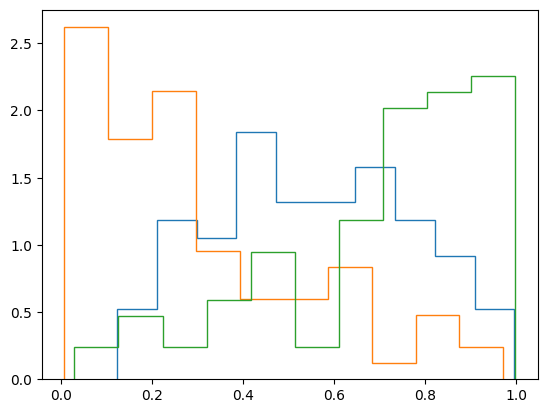

In [8]:

plt.hist(quantiles, histtype="step", density=True)
plt.hist(quantiles_m1, histtype="step", density=True)
plt.hist(quantiles_m2, histtype="step", density=True)
